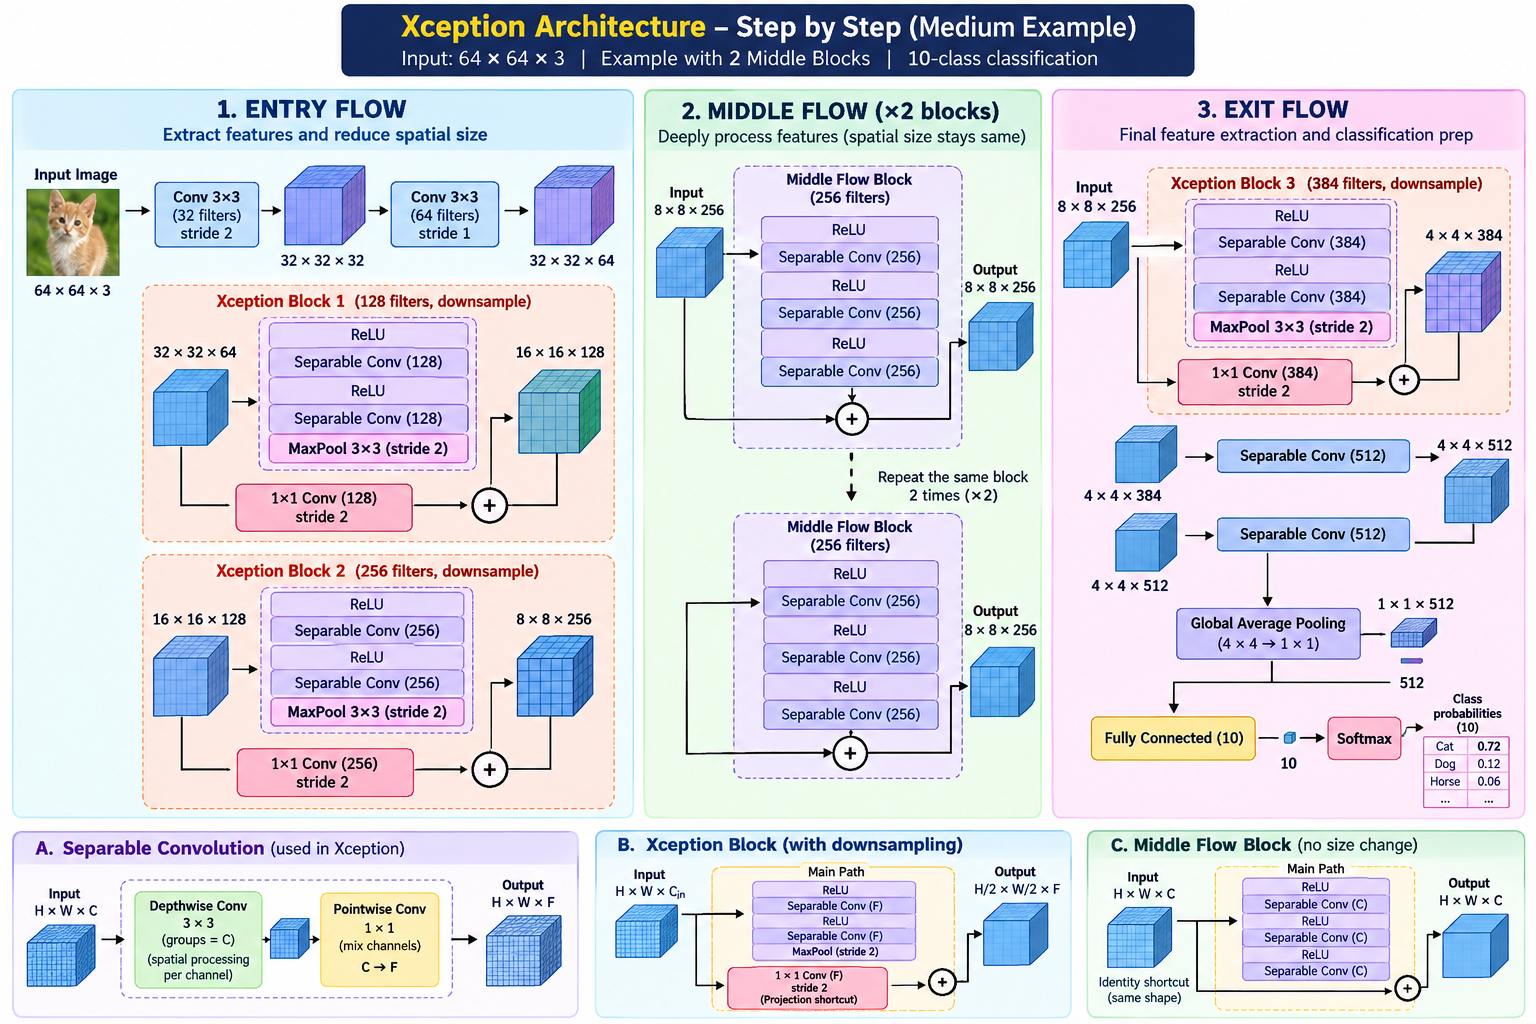

# 📘 MODULE 22.2 — XCEPTION

# 1. 🎯 Xception — Big Picture

### Xception = "Extreme Inception"

Xception was proposed by **François Chollet** in 2017.

Its central idea is:

> Take the Inception idea of separating different kinds of feature processing and push that separation to an extreme using **depthwise-separable convolutions**. ([CVPR][1])

The basic progression is:

```text
Standard Convolution
        ↓
     Inception
        ↓
More separation of spatial
and channel processing
        ↓
Depthwise-Separable Convolution
        ↓
     Xception
```

The original paper describes depthwise-separable convolution as an Inception-like operation with a maximally large number of independent towers. ([CVPR][1])

---

# 2. 🧠 Why do we need this?

A standard convolution performs two kinds of processing together:

### Spatial processing

It looks at neighboring pixels:

```text
3 × 3 neighborhood
      ↓
spatial feature extraction
```

### Channel mixing

It combines information from different input channels.

So conceptually:

```text
             Standard Conv
                   │
          ┌────────┴────────┐
          │                 │
     Spatial             Channel
    processing            mixing
          │                 │
          └────────┬────────┘
                   ↓
                Output
```

Xception separates these.

---

# 3. 🔥 Depthwise-Separable Convolution

Instead of:

```text
Input
  ↓
3×3 standard convolution
  ↓
Output
```

we perform:

```text
Input
  ↓
Depthwise 3×3
  ↓
Pointwise 1×1
  ↓
Output
```

### Depthwise convolution

Each input channel gets its own spatial filter.

```text
Channel 1 → 3×3 filter → Channel 1
Channel 2 → 3×3 filter → Channel 2
Channel 3 → 3×3 filter → Channel 3
...
```

### Pointwise convolution

Then a `1×1` convolution mixes the channels.

```text
Depthwise output
       ↓
   1×1 Conv
       ↓
Channel mixing
       ↓
Output channels
```

![Image](https://images.openai.com/static-rsc-4/gzBM8alya0tgDU2hASAl2ZDddNuNJv45-FdJGOyyMsV7HiAdOO8uT89aaJQFdr570o28CWaSUltfDhOBmxpQfrRxdPy4SHWcCDtwAgXaqQJNTFH8Yl4uHbN2YcKnY74pmcGQE35_f2ENjZeh8eB6zP-e8Qe8A5qMozVVifICUHDaqocX4B0WQe52UemOZ5E5?purpose=fullsize)

![Image](https://images.openai.com/static-rsc-4/cmD7mbpITR6WcUXjc3yRafiu9n_mksjHU-Lchmmc9g7I9zchjyUUltz_q5V3lQkL--AEKnW0l6v05yEN8QmDH0UxId9DoN4ghLru4xeTTFvMMyFSdi2URaYWJ0PoVVYqC4OiSUaPG-RNiHkeOSGkY2lGh5V8WurNJ3p6x-XfhpP-XkbzsXOWn0_Wsh7Idmiz?purpose=fullsize)

![Image](https://images.openai.com/static-rsc-4/TTGKa1q-MeUnCTjYmOvwdZDB0QKFOYaRljJket-3FExOB4ZG4mRU9EI9Xk_jyH_neGVQfLE2OJLklN3FpwsRvwarX4CcYbPJ0GmOLxSAUoupbZ3-lBv_UKY-erIU-P6AV7S8zBrSvu3Bvsrep3j_kGi0wPN5pryRTaVT6ijPc-3APLHEEyiTGxOHyMHLnRmv?purpose=fullsize)

![Image](https://images.openai.com/static-rsc-4/yHAefy3zoWM7Y4RllGUXpk3RROd7iuL4Ia44ET7ElxvteI2FhotumxGpjtKOL1NNwFCdfSEQymgjyh-gqut_ESFNFPmgZe1c5VLV5QT99nVNZI7iOtVzlge-JBAEZWAG7fPaniJreGTcHmAyfqfcWpdlY5tJcHUn5a2-DQJeqYWoOpWou4aTn03kUSfSaCJM?purpose=fullsize)

![Image](https://images.openai.com/static-rsc-4/hPCy7v5dnh8MLaWYb5rhO3knAU53aArWodPMFevmtE6vzIVJv0mtBWEudSTWFzPUMAhmPH9mvpXpl1U5nTYHKtDDiFGmMiExD2mOywJUeMIiuL40bMu90EW2Q6L-QUV7IL_bKE-U2z7JRves1fG8BHmWEHj-uZr_xM_13Vino9XPTdo0NRk58PLl5rzheZPz?purpose=fullsize)

---

# 4. 🧮 Parameter Comparison

Suppose:

```text
Input:
16 × 16 × 256

Kernel:
3 × 3

Output channels:
384
```

## Standard convolution

$$
K^2MN
$$

where:

* \(K=3\)
* \(M=256\)
* \(N=384\)

Therefore:

$$
3^2\times256\times384
$$

$$
=\boxed{884,736}
$$

---

## Depthwise convolution

$$
K^2M
$$

$$
=3^2\times256
$$

$$
=\boxed{2,304}
$$

---

## Pointwise convolution

$$
MN
$$

$$
=256\times384
$$

$$
=\boxed{98,304}
$$

---

## Total

$$
2,304+98,304
=
\boxed{100,608}
$$

Comparison:

$$
\frac{884,736}{100,608}
\approx8.8
$$

So:

$$
\boxed{\text{~8.8× fewer parameters}}
$$

This is the fundamental computational advantage that Xception inherits from depthwise-separable convolution.

---

# 5. 🚨 The MOST IMPORTANT: MobileNet vs Xception

This deserves its own section.

Both use:

$$
\boxed{\text{Depthwise-Separable Convolution}}
$$

But **their architectural goals and organization are different**.

---

## 🟦 MobileNet

The original MobileNet was explicitly designed for **mobile and embedded vision applications**.

Its architecture uses depthwise-separable convolutions to construct lightweight CNNs and introduces two global hyperparameters:

* **Width multiplier \(\alpha\)**
* **Resolution multiplier \(\rho\)**

These let developers trade accuracy for latency/computation. ([arXiv][2])

Conceptually:

```text
MobileNet
    │
    ├── Depthwise Conv
    │
    ├── Pointwise Conv
    │
    ├── Lightweight architecture
    │
    ├── α → control width
    │
    └── ρ → control resolution
```

---

## 🟧 Xception

Xception starts from a different architectural motivation.

It asks:

> What if the Inception idea of separating feature processing were pushed all the way toward depthwise-separable convolution?

The resulting architecture uses:

```text
Entry Flow
     ↓
Middle Flow ×8
     ↓
Exit Flow
```

and uses separable convolutions throughout its major blocks together with residual shortcuts. ([CVPR][3])

Conceptually:

```text
Xception
    │
    ├── Inception-inspired separation
    │
    ├── Depthwise-separable Conv
    │
    ├── Residual blocks
    │
    ├── Entry Flow
    │
    ├── Middle Flow ×8
    │
    └── Exit Flow
```

---

# 6. 📊 MobileNet vs Xception — Full Comparison

| Feature                | **MobileNet V1**                   | **Xception**                                   |
| ---------------------- | ---------------------------------- | ---------------------------------------------- |
| Main motivation        | Efficient mobile/embedded vision   | Extreme version of Inception's separation idea |
| Core operation         | Depthwise-separable convolution    | Depthwise-separable convolution                |
| Origin/idea            | Lightweight CNN design             | Inception → extreme separation                 |
| Architecture           | Lightweight sequential CNN         | Entry → Middle → Exit flows                    |
| Residual connections   | Not a defining feature of V1       | Used throughout Xception blocks                |
| Width multiplier       | ✅ \(\alpha\)                       | Not its defining mechanism                     |
| Resolution multiplier  | ✅ \(\rho\)                         | Not its defining mechanism                     |
| Middle repeated blocks | Not the Xception-style Middle Flow | ✅ Middle Flow repeated 8×                      |
| Main design emphasis   | Low resource usage                 | Efficient parameter use + deep representation  |
| Typical mental model   | "Make CNN lightweight"             | "Push Inception separation to the extreme"     |

MobileNet's original paper explicitly focuses on mobile/embedded applications and resource/accuracy trade-offs. Xception's paper instead frames the architecture as an Inception-inspired replacement using depthwise-separable convolutions. ([arXiv][2])

---

# 7. 🚨 Xception ≠ MobileNet + Residual

This is **VERY important**.

You previously asked exactly this, so let's permanently lock it into the notes. ❤️

### Wrong idea:

```text
MobileNet
    +
Residual connection
    =
Xception
```

❌ **No.**

Instead:

```text
Depthwise-Separable Conv
          │
          ├── used by MobileNet
          │
          └── used by Xception


Residual Connection
          │
          └── separate architectural idea
```

Xception combines separable convolutions with residual organization, but its conceptual origin is the **Inception → extreme separation** interpretation, not "take MobileNet and add shortcuts." ([CVPR][1])

---

# 8. 🧠 Two independent architectural switches

This is probably the **best mental model** to remember.

### Switch 1 — How do we perform convolution?

```text
Standard
   vs
Depthwise + Pointwise
```

This controls **computational efficiency**.

---

### Switch 2 — How do blocks connect?

```text
Sequential
   vs
Residual
```

This controls **information/gradient flow and block organization**.

Therefore:

```text
                 CNN block
                    │
          ┌─────────┴─────────┐
          │                   │
   Convolution type       Connection type
          │                   │
          ▼                   ▼
 Standard / Separable    Sequential / Residual
```

This prevents the common confusion.

---

# 9. 🧩 Residual Connection

Basic residual connection:

$$
\boxed{Y=F(X)+X}
$$

where:

* \(X\) = input
* \(F(X)\) = learned transformation
* \(Y\) = output

Conceptually:

```text
             ┌──────────────┐
             │              │
Input ───────┤ Main path     │
             │ F(X)          │
             └──────┬───────┘
                    │
                    ▼
                   (+)
                    ▲
                    │
Input ──────────────┘
                    │
                    ▼
                  Output
```

---

# 10. 🔧 Projection Shortcut

What happens if the dimensions change?

Example:

```text
Input:
16 × 16 × 128
```

Main branch:

```text
SepConv → 256
       ↓
MaxPool stride 2
       ↓
8 × 8 × 256
```

Shortcut is still:

```text
16 × 16 × 128
```

You cannot add them.

So use:

```text
1×1 Conv
128 → 256
stride = 2
```

giving:

```text
8 × 8 × 256
```

Now:

```text
Main branch       Shortcut
8×8×256           8×8×256
      \             /
       \           /
          ADD
           │
           ▼
       8×8×256
```

Mathematically:

$$
\boxed{Y=F(X)+P(X)}
$$

where \(P(X)\) is the projection shortcut.

---

# 11. 🏗️ Xception Block

A simplified Xception block:

```text
                         Shortcut
                            │
                         1×1 Conv
                         stride 2
                            │
                            ▼
Input ───────┐            (+)
             │             ▲
             ▼             │
            ReLU           │
             ↓              │
           SepConv          │
             ↓              │
            ReLU            │
             ↓              │
           SepConv          │
             ↓              │
          MaxPool           │
             └──────────────┘
```

Both branches must have matching dimensions before `+`.

---

# 12. 🏗️ Original Xception Architecture

The original Xception architecture has three major flows:

```text
┌─────────────────────┐
│     ENTRY FLOW      │
└──────────┬──────────┘
           ↓
┌─────────────────────┐
│    MIDDLE FLOW      │
│        ×8           │
└──────────┬──────────┘
           ↓
┌─────────────────────┐
│      EXIT FLOW      │
└──────────┬──────────┘
           ↓
          GAP
           ↓
       Classifier
```

The original architecture starts from a **299×299×3** input and reaches **19×19×728** before the Middle Flow. ([CVPR][3])

![Image](https://images.openai.com/static-rsc-4/sYhml7Up7E449gVLMpH4U3qqgBh8JR35rp57se6Ff57vOM5dL621QjcSqlS_JjZTSgp9bDychbfrRmhb8wlZXLr2oCqLfZxu6IREj287x7c9xFR4BV-fy6eQZb4dn17VKcORx8NV4Ckgn7lAcTGw2fsYach3btcVsAkTiQOKtYAaD7vpgvPltjS5ZxCDCT5F?purpose=fullsize)

![Image](https://images.openai.com/static-rsc-4/EVafIMcarCGvIoPuPPg3XX8kmUXoH6178Q5w8aNlIuxyg4dO-TJPPoTYzOJRBa8O4qKE5sRp6EVzePHRnDGg8zPuMGQkaGDKsjFybpl6Ff8-PoziORhnWGUl_X2CpVsMGU3Cl3WlW0XGSxIqQ-_ZMj49LPYuxkdlJt4Ta8NBEnu0mWKwARSXeQ0CoXk__czN?purpose=fullsize)

![Image](https://images.openai.com/static-rsc-4/NbIfuqmKl4g2hNpFeKvmmZQO01b2sGns0eVoT0v8l-6tulAfkT4pdcZoL3shWDYgYetvTXM2ZQkCzalckdDi726YZkV9096eMZ-otQ6vFXYvUojKjHE1hgYoT0e6g9C-CIG-kDsZBMTpNxWb8EvXJyvTGpY_MlnHczwBz0--ZPwrRdo1YDFHBCLIpmeMCND5?purpose=fullsize)

![Image](https://images.openai.com/static-rsc-4/rwYGkxH7m6VG3eAB6UYaqw5QIFEdCinDiUGDtPeHY8yBavJAlVtdzPzK_-QvTmPlWXUtFlbkwtB6oTcAguPOcj1mvxVQU6fgdaVDtrTi_MSYwcPgx4NeU-NlfAaWo3sBmbGd3HMXG_oYVAAxC6APfxp0Y5iXPWFlvvAqJoxiLnano5FA_5WWHVdQsQEZyL66?purpose=fullsize)

---

# 13. 🚪 Entry Flow

The Entry Flow performs early feature extraction and downsampling.

Simplified flow:

```text
299 × 299 × 3
       ↓
Conv 3×3, 32
stride 2
       ↓
Conv 3×3, 64
       ↓
Xception Block
       ↓
128 channels
       ↓
Xception Block
       ↓
256 channels
       ↓
Xception Block
       ↓
728 channels
       ↓
19 × 19 × 728
```

### Pattern

Spatial dimensions:

```text
Large
 ↓
Smaller
 ↓
Smaller
 ↓
19×19
```

Channels:

```text
3
↓
32
↓
64
↓
128
↓
256
↓
728
```

So:

> **Spatial resolution decreases while feature/channel richness increases.**

---

# 14. 🔁 Middle Flow

This is a very important part of Xception.

One Middle Flow block contains:

```text
Input
  ↓
ReLU
  ↓
SepConv 728
  ↓
ReLU
  ↓
SepConv 728
  ↓
ReLU
  ↓
SepConv 728
  ↓
+
  ↑
Shortcut
```

And this block is repeated:

$$
\boxed{8\text{ times}}
$$

The key point:

### Spatial dimensions stay constant.

```text
19 × 19 × 728
        ↓
19 × 19 × 728
        ↓
19 × 19 × 728
        ↓
...
```

The Middle Flow therefore focuses on **deep feature refinement without additional spatial downsampling**. ([CVPR][3])

---

# 15. 🚪 Exit Flow

The Exit Flow resumes downsampling and increases feature channels.

Conceptually:

```text
19 × 19 × 728
       ↓
SepConv
       ↓
Downsampling
       ↓
8 × 8 × 1024
       ↓
SepConv
       ↓
1536 channels
       ↓
SepConv
       ↓
2048 channels
       ↓
Global Average Pooling
       ↓
2048
       ↓
Classifier
```

The original architecture ends its convolutional feature extractor at 2048 channels before global average pooling. ([CVPR][3])

---

# 16. 🖼️ Xception Architecture Visual

![Image](https://images.openai.com/static-rsc-4/sYhml7Up7E449gVLMpH4U3qqgBh8JR35rp57se6Ff57vOM5dL621QjcSqlS_JjZTSgp9bDychbfrRmhb8wlZXLr2oCqLfZxu6IREj287x7c9xFR4BV-fy6eQZb4dn17VKcORx8NV4Ckgn7lAcTGw2fsYach3btcVsAkTiQOKtYAaD7vpgvPltjS5ZxCDCT5F?purpose=fullsize)

![Image](https://images.openai.com/static-rsc-4/EQhnzwQneL6L31q7La0zgg7HR0tvOrsY1bYRhjo6P6oNlKvlUoV9YQZeomEQznjzePRBdF0siHN2U921SIskBpKx5EwfG9G0mLNM4ZflrjUyfvdsDj-O_OHP7VcsxmH-9PJedFacOxYUME63WfLRYzjAhjpwW4XFMdOyOqNtg-hH-uclKGCmWC5lFALuRDeD?purpose=fullsize)

![Image](https://images.openai.com/static-rsc-4/kXu6YthZ8aFUmsFISwD1OPadCvRZVXbUrFL5GW0352mY9ADLKJQUysMx4FLPcvcqXMJl2W-ZHrX8x5jIdlI3IgEnTjamoMp2k7vvbpkfVHdhh3PDtG7CWGtDB5oB0c3wLeAmlkmNd_EbRkD2c8gxzk10PqdKTGXAHEzLJH24UXfplhGixeqGqp-FQ95gl86j?purpose=fullsize)

When looking at the architecture, don't try to memorize every tiny box.

Instead identify:

```text
ENTRY
  ↓
MIDDLE ×8
  ↓
EXIT
  ↓
GAP
  ↓
CLASSIFIER
```

That's your first-level understanding.

---

# 17. 🧮 Numerical Xception Block

Let's use the medium example we studied.

Input:

$$
16\times16\times128
$$

Desired output:

$$
8\times8\times256
$$

### Main branch

```text
16×16×128
      ↓
SepConv 256
      ↓
SepConv 256
      ↓
MaxPool stride 2
      ↓
8×8×256
```

### Shortcut

```text
16×16×128
      ↓
1×1 Conv
128 → 256
stride 2
      ↓
8×8×256
```

Then:

$$
8\times8\times256
+
8\times8\times256
$$

giving:

$$
\boxed{8\times8\times256}
$$

---

# 18. 🔢 Parameter Calculation for the Block

For a standard 3×3 convolution:

```text
Input = 128
Output = 256
```

Parameters:

$$
3^2\times128\times256
$$

$$
=\boxed{294,912}
$$

---

### Depthwise

$$
3^2\times128
$$

$$
=\boxed{1,152}
$$

### Pointwise

$$
128\times256
$$

$$
=\boxed{32,768}
$$

### Separable total

$$
1,152+32,768
=
\boxed{33,920}
$$

Comparison:

$$
\frac{294,912}{33,920}
\approx8.7
$$

So approximately:

$$
\boxed{8.7\times\text{ fewer parameters}}
$$

---

# 19. 🧮 Another computational comparison

For:

```text
H = W = 16
Cin = 256
Cout = 384
K = 3
```

### Standard convolution MACs

$$
16\times16\times3\times3\times256\times384
$$

$$
=\boxed{226,492,416}
$$

≈ **226.5M MACs**

---

### Depthwise

$$
16\times16\times3\times3\times256
$$

$$
=589,824
$$

### Pointwise

$$
16\times16\times256\times384
$$

$$
=25,165,824
$$

### Total

$$
589,824+25,165,824
$$

$$
=\boxed{25,755,648}
$$

≈ **25.8M MACs**

So the computation is roughly:

$$
\frac{226.5M}{25.8M}
\approx8.8
$$

times smaller.

---

# 20. ⚠️ FLOPs/MACs ≠ actual latency

Very important from your **MobileNet studies**.

A model having fewer MACs does **not automatically mean it will be exactly that many times faster**.

Real latency depends on:

* CPU/GPU/NPU architecture
* memory access
* kernel implementation
* framework
* batch size
* operator fusion
* hardware optimization

So:

$$
\boxed{\text{Lower MACs} \neq \text{guaranteed proportional latency reduction}}
$$

This matters heavily when deploying CNNs on actual edge devices.

---

# 21. 🧠 Global Average Pooling

Suppose final feature map:

```text
4 × 4 × 512
```

For one channel:

```text
2  4
6  8
```

Average:

$$
\frac{2+4+6+8}{4}
=
5
$$

Do this for every channel.

Therefore:

```text
4 × 4 × 512
       ↓
Global Average Pooling
       ↓
512
```

Instead of flattening:

$$
4\times4\times512=8192
$$

we directly get:

$$
\boxed{512}
$$

---

# 22. 🧪 Our Medium Xception Example

⚠️ **This is a teaching architecture, NOT the exact original Xception architecture.**

We used:

```text
Input
64 × 64 × 3
       ↓
Conv 32 / stride 2
       ↓
32 × 32 × 32
       ↓
Conv 64
       ↓
32 × 32 × 64
       ↓
Xception Block 1
       ↓
16 × 16 × 128
       ↓
Xception Block 2
       ↓
8 × 8 × 256
       ↓
Middle Flow ×2
       ↓
8 × 8 × 256
       ↓
Exit Block
       ↓
4 × 4 × 384
       ↓
SepConv 512
       ↓
4 × 4 × 512
       ↓
GAP
       ↓
512
       ↓
FC
       ↓
10 classes
```

The actual Xception architecture uses **Middle Flow ×8**.

Our ×2 example was only created to make the architecture easier to understand.

---

# 23. 🖼️ Medium Xception Mental Visualization

```text
                         INPUT
                       64×64×3
                           │
                           ▼
                    ┌─────────────┐
                    │ ENTRY FLOW  │
                    └──────┬──────┘
                           │
                           ▼
                     8×8×256
                           │
             ┌─────────────┴─────────────┐
             │                           │
             │       MIDDLE FLOW         │
             │                           │
             │        SepConv            │
             │        SepConv            │
             │        SepConv            │
             │          +                │
             │                           │
             │          ×2               │
             └─────────────┬─────────────┘
                           │
                           ▼
                    ┌─────────────┐
                    │  EXIT FLOW  │
                    └──────┬──────┘
                           │
                           ▼
                       4×4×512
                           │
                           ▼
                         GAP
                           │
                           ▼
                          512
                           │
                           ▼
                       10 classes
```

---

# 24. 💻 PyTorch — Separable Convolution

Current PyTorch documentation confirms that when `groups == in_channels`, each input channel is convolved independently, which is the depthwise-convolution configuration. ([PyTorch Docs][4])

```python
import torch
import torch.nn as nn


class SeparableConv(nn.Module):

    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.depthwise = nn.Conv2d(
            in_channels,
            in_channels,
            kernel_size=3,
            padding=1,
            groups=in_channels,
            bias=False
        )

        self.pointwise = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=1,
            bias=False
        )

        self.bn = nn.BatchNorm2d(out_channels)

    def forward(self, x):

        x = self.depthwise(x)
        x = self.pointwise(x)
        x = self.bn(x)

        return x
```

The key line:

```python
groups=in_channels
```

means:

```text
Channel 1 → own spatial filters
Channel 2 → own spatial filters
Channel 3 → own spatial filters
...
```

followed by:

```python
kernel_size=1
```

for channel mixing.

---

# 25. 🧱 Simplified Xception Block — PyTorch

```python
class XceptionBlock(nn.Module):

    def __init__(self, in_channels, out_channels, downsample=True):

        super().__init__()

        stride = 2 if downsample else 1

        self.sep1 = SeparableConv(
            in_channels,
            out_channels
        )

        self.sep2 = SeparableConv(
            out_channels,
            out_channels
        )

        self.relu = nn.ReLU()

        self.pool = nn.MaxPool2d(
            kernel_size=3,
            stride=stride,
            padding=1
        )

        if in_channels != out_channels or downsample:

            self.shortcut = nn.Sequential(

                nn.Conv2d(
                    in_channels,
                    out_channels,
                    kernel_size=1,
                    stride=stride,
                    bias=False
                ),

                nn.BatchNorm2d(out_channels)
            )

        else:

            self.shortcut = nn.Identity()

    def forward(self, x):

        residual = self.shortcut(x)

        x = self.relu(x)
        x = self.sep1(x)

        x = self.relu(x)
        x = self.sep2(x)

        x = self.pool(x)

        x = x + residual

        return x
```

Test:

```python
x = torch.randn(1, 128, 16, 16)

block = XceptionBlock(
    128,
    256,
    downsample=True
)

y = block(x)

print(x.shape)
print(y.shape)
```

Output:

```text
torch.Size([1, 128, 16, 16])

torch.Size([1, 256, 8, 8])
```

---

# 26. 🔍 How to Read an Xception Architecture Diagram

Don't read every box individually.

Use this order:

### Step 1 — Identify the flows

```text
Entry
 ↓
Middle ×8
 ↓
Exit
```

### Step 2 — Track spatial size

```text
299×299
   ↓
149×149
   ↓
...
   ↓
19×19
   ↓
8×8
   ↓
GAP
```

### Step 3 — Track channels

```text
3
↓
32
↓
64
↓
128
↓
256
↓
728
↓
1024
↓
1536
↓
2048
```

### Step 4 — Find `+`

That means:

```text
Residual addition
```

### Step 5 — Find `SepConv`

That tells you where the depthwise-separable convolution is being used.

---

# 27. 🧠 Xception's Core Philosophy

This is the deeper understanding you should carry forward.

### Standard CNN

```text
Spatial
   +
Channel
   │
   ▼
Together
```

### Inception

```text
Different spatial transformations
        ↓
Partial separation
```

### Xception

```text
Spatial processing
        ↓
Depthwise

        +

Channel mixing
        ↓
Pointwise
```

The original Xception paper specifically presents this as a continuum:

$$
\boxed{
\text{Regular Conv}
\rightarrow
\text{Inception}
\rightarrow
\text{Depthwise-Separable Conv}
}
$$

and builds Xception from that interpretation. ([CVPR][1])

---

# 28. 🆚 Final MobileNet vs Xception Mental Model

This is the section I want you to **memorize conceptually**, not word-for-word.

```text
                         DEPTHWISE
                         SEPARABLE
                        CONVOLUTION
                             │
              ┌──────────────┴──────────────┐
              │                             │
              ▼                             ▼
          MobileNet                      Xception
              │                             │
              ▼                             ▼
       Mobile / Edge                 Inception-inspired
          efficiency                   architecture
              │                             │
              ├── α width                   ├── Entry Flow
              │                             │
              ├── ρ resolution              ├── Middle Flow ×8
              │                             │
              └── Lightweight                ├── Exit Flow
                  CNN                        │
                                            └── Residual
                                                blocks
```

### One-line memory trick:

> **MobileNet = depthwise separable convolution optimized around lightweight/mobile deployment.**

> **Xception = depthwise separable convolution taken from the "extreme Inception" viewpoint and organized into a deep residual architecture.**

MobileNet's original paper explicitly targets mobile/embedded vision and introduces α/ρ resource trade-offs; Xception's paper derives its architecture from the Inception/depthwise-separable interpretation. ([arXiv][2])

---

# 29. 🎤 Interview Question: "What is Xception?"

### 30-second answer

> **Xception is a convolutional neural network architecture proposed by François Chollet that takes the Inception concept of separating feature processing to an extreme using depthwise-separable convolutions. A depthwise convolution performs spatial filtering independently per channel, followed by a 1×1 pointwise convolution for channel mixing. Xception organizes these operations into Entry, Middle, and Exit flows, with the Middle Flow repeated eight times, and uses residual connections around its blocks.** ([CVPR][1])

---

# 30. 🎤 Interview Question: "How is Xception different from MobileNet?"

A good answer:

> **Both use depthwise-separable convolutions, but they were motivated differently. MobileNet V1 was designed as a lightweight CNN for mobile and embedded vision and introduced width and resolution multipliers to control resource usage. Xception was derived from an Inception-inspired idea of extreme separation between spatial and channel processing, and its architecture is organized into Entry, Middle, and Exit flows with residual connections. Therefore Xception is not simply MobileNet with residual connections.** ([arXiv][2])

---

# 31. 🎤 Interview Question: "Why is Xception efficient?"

Answer:

> **Its main efficiency comes from replacing expensive standard convolutions with depthwise-separable convolutions. A standard \(K\times K\) convolution requires \(K^2MN\) parameters, whereas depthwise-separable convolution requires approximately \(K^2M+MN\). This substantially reduces parameters and multiply-accumulate operations, although actual hardware latency depends on implementation and hardware.**

---

# 32. 🎤 Interview Question: "Why do we need the shortcut?"

Because the shortcut creates a direct information path:

$$
Y=F(X)+X
$$

or:

$$
Y=F(X)+P(X)
$$

when dimensions change.

The shortcut and separable convolution solve **different problems**:

```text
Separable Conv
      ↓
Computational efficiency


Residual Shortcut
      ↓
Information / gradient pathway
```

🔥 **Don't mix these two concepts.**

---

# 33. ⚠️ Important Trade-offs

### Advantages

✅ Fewer convolution parameters
✅ Lower computational cost
✅ Efficient feature extraction
✅ Deep architecture
✅ Residual information paths
✅ Strong parameter utilization
✅ Useful CNN backbone

The original paper reports that Xception had the **same number of parameters as Inception V3** in its comparison while achieving better reported performance, supporting the paper's argument that the gains were not simply from increased parameter count. ([CVPR][1])

### Limitations

⚠️ Fewer MACs don't guarantee proportional hardware speedup.

⚠️ Depthwise operations can have different hardware efficiency from dense convolutions.

⚠️ Xception is more structurally complex than the basic MobileNet V1 design.

⚠️ Deployment performance depends on the target hardware, kernels, memory access and framework.

---

# 34. 🌍 Industry Connection

Xception is important beyond ImageNet classification.

One notable connection is **DeepLabv3+**, where an Xception-based encoder was explored for semantic segmentation and depthwise separable convolutions were used in the architecture. ([CVPR][5])

Conceptually:

```text
Xception
    ↓
Efficient CNN backbone
    ↓
Computer Vision
 ┌─────────────┬──────────────┐
 ↓             ↓              ↓
Classification Detection   Segmentation
```

---

# 35. 📚 Online Resources + Visuals

### 📄 Original Xception paper

[Xception — CVPR 2017 Open Access](https://openaccess.thecvf.com/content_cvpr_2017/html/Chollet_Xception_Deep_Learning_CVPR_2017_paper.html?utm_source=chatgpt.com)

This should be your **primary reference** for the architecture and the Inception → depthwise-separable interpretation.

### 📄 Original MobileNet paper

[MobileNets — Efficient Convolutional Neural Networks for Mobile Vision Applications](https://arxiv.org/abs/1704.04861?utm_source=chatgpt.com)

Useful specifically for the MobileNet V1 design, depthwise-separable convolution, α and ρ.

### 🧑‍💻 PyTorch Conv2d documentation

[PyTorch Conv2d — official documentation](https://docs.pytorch.org/docs/main/generated/torch.nn.Conv2d.html?utm_source=chatgpt.com)

Especially useful for understanding:

```python
groups=in_channels
```

and how PyTorch implements depthwise convolution.

---

# 36. 🧠 FINAL XCEPTION MEMORY MAP

```text
                         XCEPTION
                            │
                            ▼
                 "Extreme Inception"
                            │
                            ▼
             Separate spatial + channel
                     processing
                            │
                            ▼
              DEPTHWISE-SEPARABLE CONV
                     /           \
                    /             \
             Depthwise          Pointwise
                3×3                1×1
                 │                  │
          spatial filtering    channel mixing
                    \             /
                     \           /
                       OUTPUT
                          │
                          ▼
                 Xception Blocks
                          │
                 Residual shortcuts
                          │
          ┌───────────────┼───────────────┐
          ▼               ▼               ▼
       ENTRY           MIDDLE            EXIT
                       ×8
          │               │               │
          └───────────────┼───────────────┘
                          │
                          ▼
                    Global Average
                       Pooling
                          │
                          ▼
                      Classifier
```

---

# 🔥 THE 5 THINGS YOU MUST REMEMBER

### 1️⃣ Xception's core operation

$$
\boxed{\text{Depthwise Conv}+\text{Pointwise Conv}}
$$

### 2️⃣ Xception's conceptual origin

$$
\boxed{\text{Inception → extreme separation}}
$$

### 3️⃣ Main architecture

$$
\boxed{\text{Entry → Middle ×8 → Exit}}
$$

### 4️⃣ Residual connection

$$
\boxed{Y=F(X)+X}
$$

or:

$$
\boxed{Y=F(X)+P(X)}
$$

### 5️⃣ MobileNet distinction

$$
\boxed{\text{Xception}\neq\text{MobileNet + Residual}}
$$

Instead:

```text
MobileNet
→ lightweight/mobile-focused design
→ depthwise separable
→ α + ρ


Xception
→ extreme Inception interpretation
→ depthwise separable
→ Entry/Middle/Exit
→ residual architecture
```

---

